# 🇨🇴 Multivariable Regression Model for Property Valuation

A data-driven exploration of the **Boston Housing dataset** from the 1970s with the goal of estimating residential property values using multivariable regression techniques.

This analysis simulates the type of evaluation that a real estate development firm would perform before investing in a residential project.

In practical terms, a data scientist would like to answer a key question:

> Given a property's characteristics, what is a reasonable estimate for its market value?

To address this question, a regression model will be constructed using features such as:

- Number of rooms in the dwelling
- Distance to employment centers
- Environmental conditions
- Socioeconomic indicators of the surrounding neighborhood
- Educational infrastructure (student–teacher ratio)

---

## Objectives of the Analysis

This project follows a structured workflow common in applied data science:

1. Explore and understand the Boston housing dataset
2. Perform initial data inspection and descriptive analysis
3. Visualize patterns and relationships between variables
4. Split the dataset into training and testing sets
5. Train a multivariable linear regression model
6. Evaluate model coefficients and residuals
7. Apply data transformation techniques to improve performance
8. Use the model to estimate property prices

---

## Analytical Perspective

Rather than focusing only on technical metrics, the objective is to understand how neighborhood characteristics influence housing prices and how statistical modeling can capture these dynamics.

> Interpretation and context matter as much as numerical results.

---

## 🛠 Import Statements

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Machine learning tools
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Display settings
pd.options.display.float_format = '{:,.2f}'.format

---
## 🎨 Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

---
## 📂 Read the Dataset


In [3]:
data = pd.read_csv('boston.csv', index_col=0)
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20


### Understand the Boston House Price Dataset

The dataset contains **506 observations** representing residential areas in Boston.

Each observation includes **13 explanatory variables** and one **target variable** representing the median property value.

The first column in the dataset represents row identifiers and will be used as the **index**.

Dataset Overview

- Observations: 506
- Predictive Features: 13
- Target Variable: Median housing price (**PRICE**)

**Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. The Median Value (attribute 14) is the target.

    :Attribute Information (in order):
        1. CRIM     per capita crime rate by town
        2. ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        3. INDUS    proportion of non-retail business acres per town
        4. CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        5. NOX      nitric oxides concentration (parts per 10 million)
        6. RM       average number of rooms per dwelling
        7. AGE      proportion of owner-occupied units built prior to 1940
        8. DIS      weighted distances to five Boston employment centres
        9. RAD      index of accessibility to radial highways
        10. TAX      full-value property-tax rate per $10,000
        11. PTRATIO  pupil-teacher ratio by town
        12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        13. LSTAT    % lower status of the population
        14. PRICE     Median value of owner-occupied homes in $1000's
        
    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

This is a copy of [UCI ML housing dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/housing/). This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University. You can find the [original research paper here](https://deepblue.lib.umich.edu/bitstream/handle/2027.42/22636/0000186.pdf?sequence=1&isAllowed=y). 

---

## 🔎 Preliminary Data Exploration 

Before building a predictive model, it is essential to verify the dataset’s structure.

The following checks will confirm:

- dataset dimensions
- data types
- potential missing values
- duplicate records

These steps form the foundation of responsible data analysis.

---

In [4]:
print(f"Dataset rows: {data.shape[0]}")
print(f"Dataset columns: {data.shape[1]}")

data.info()

Dataset rows: 506
Dataset columns: 14
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


## 🧹 Data Cleaning - Check for Missing Values and Duplicates

A model is only as reliable as the data used to train it.

Two quick diagnostics are performed:

- Missing values
- Duplicate records

In [5]:
print("Missing values present:", data.isna().values.any())
print("Duplicate rows present:", data.duplicated().values.any())

Missing values present: False
Duplicate rows present: False


---
## 📊 Descriptive Statistics

Understanding summary statistics provides important insights into the dataset.

Key questions explored:

- What is the average housing price?
- What is the typical classroom size?
- What range of housing sizes exists in the dataset?

In [6]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [7]:
mean_students_teacher = data['PTRATIO'].mean()
mean_price = data['PRICE'].mean()

print(f"Average students per teacher: {mean_students_teacher:.2f}")
print(f"Average property price: {mean_price:.2f}")

Average students per teacher: 18.46
Average property price: 22.53


### Feature Interpretation
`CHAS` — River Proximity

The `CHAS` variable is a binary indicator showing whether a property borders the Charles River.

Values:

- 0 → not near the river
- 1 → located next to the river

In modeling terms, this is known as a dummy variable.

---

## 📈 Distribution Analysis

To better understand the data, several key variables are visualized:

- Housing prices
- Number of rooms
- Distance to employment
- Highway accessibility

Distribution plots reveal whether variables follow **normal distributions** or exhibit **skewness**.

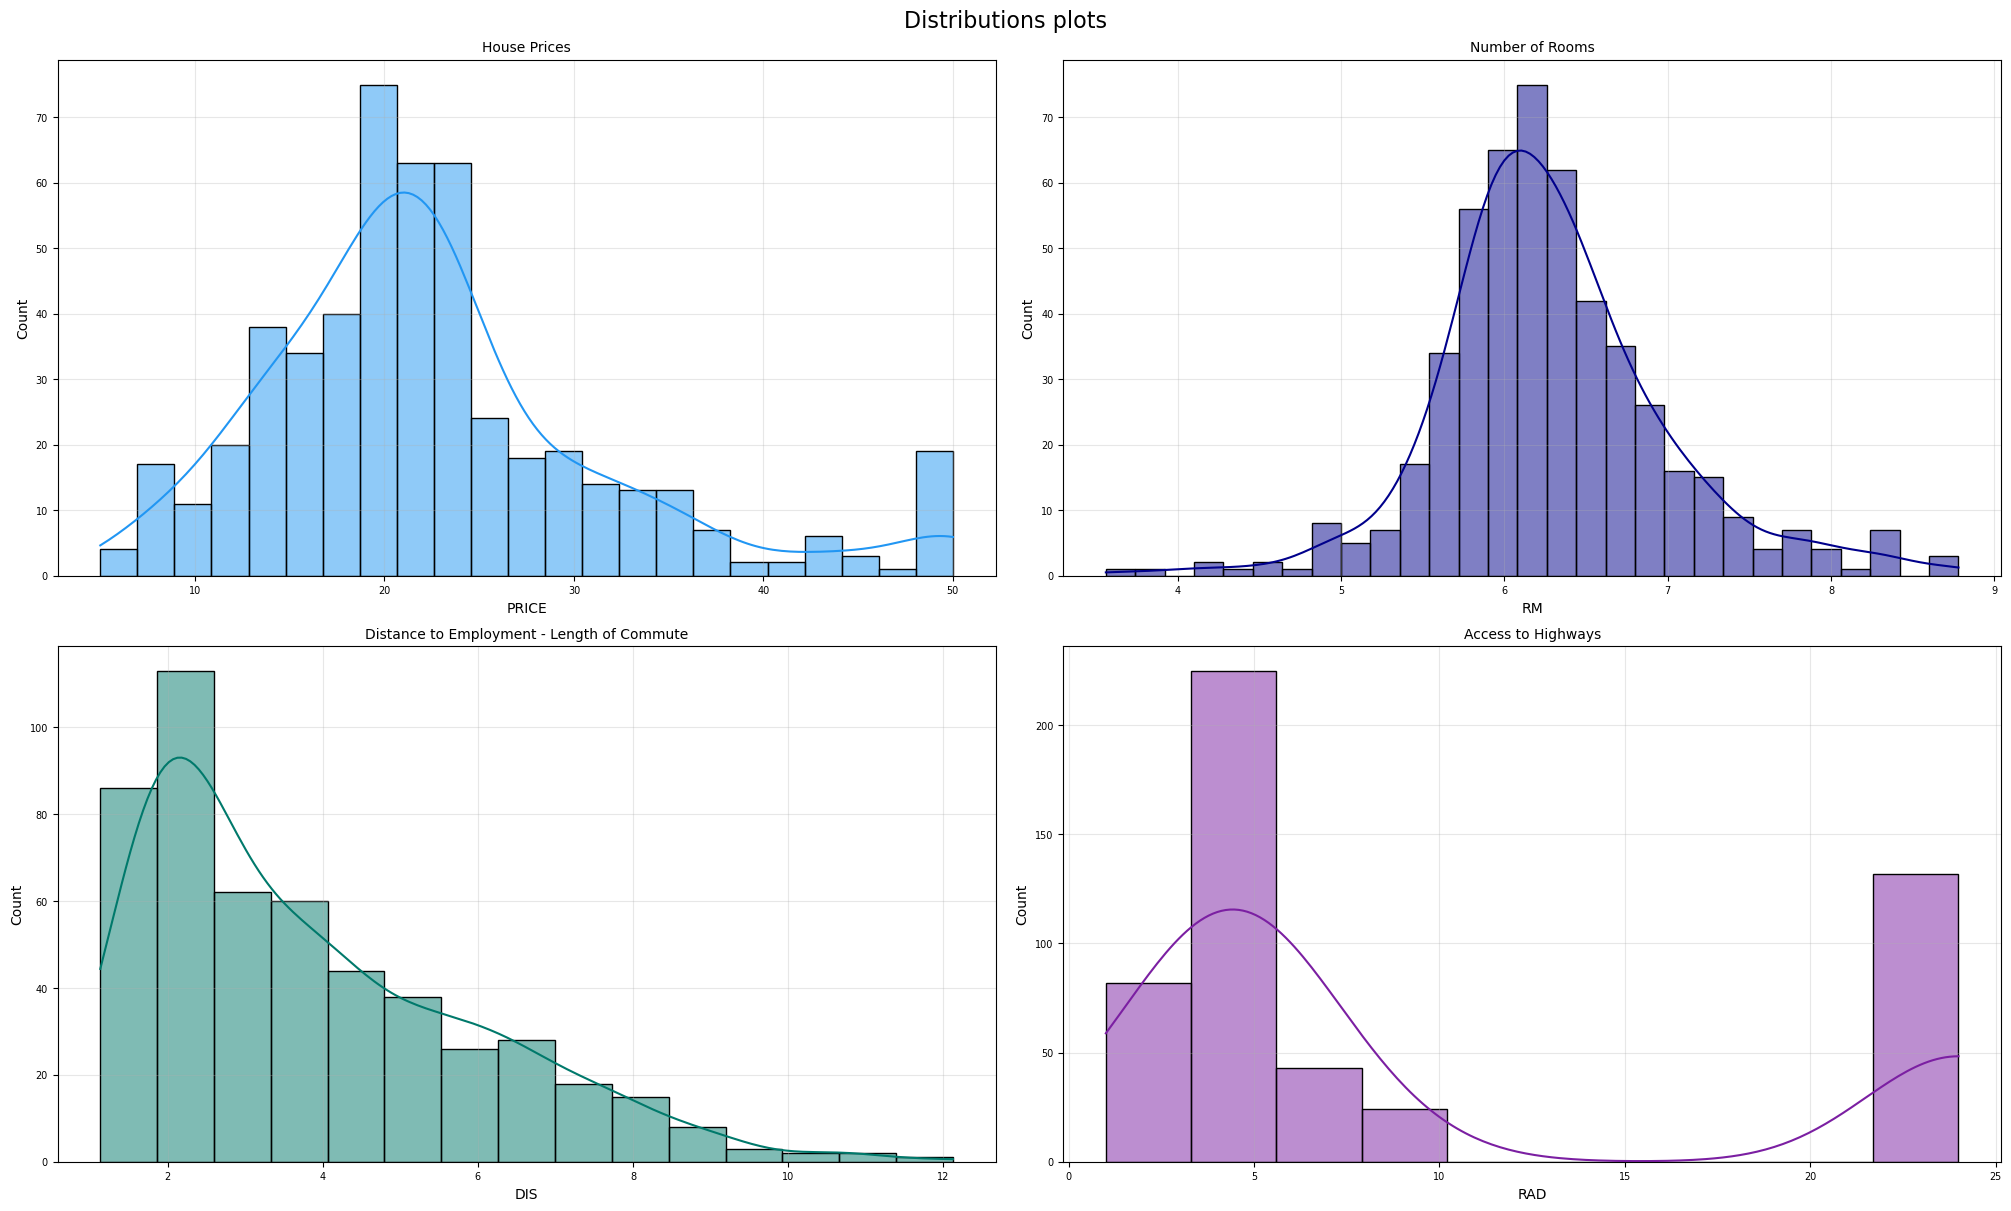

In [8]:
# Convert columns to list
column_list = ['PRICE','RM','DIS','RAD']
column_names=['House Prices','Number of Rooms',
              'Distance to Employment - Length of Commute','Access to Highways']
colors=['#2196f3','darkblue','#00796b','#7b1fa2']

# Define grid parameters
n_cols = 2
n_rows = 2

# Create grid
fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 12), layout="constrained")

for i, col in enumerate(column_list):
    ax = axs.flat[i]
    
    sns.histplot(data=data, x=col, kde=True,ax=ax,color=colors[i])
    
    ax.set_title(f'{column_names[i]}', fontsize=10)
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(column_list), n_rows * n_cols):
    axs.flat[j].axis('off')

fig.suptitle("Distributions plots", fontsize=16)

plt.show()

### ⛵️ River Proximity Visualization

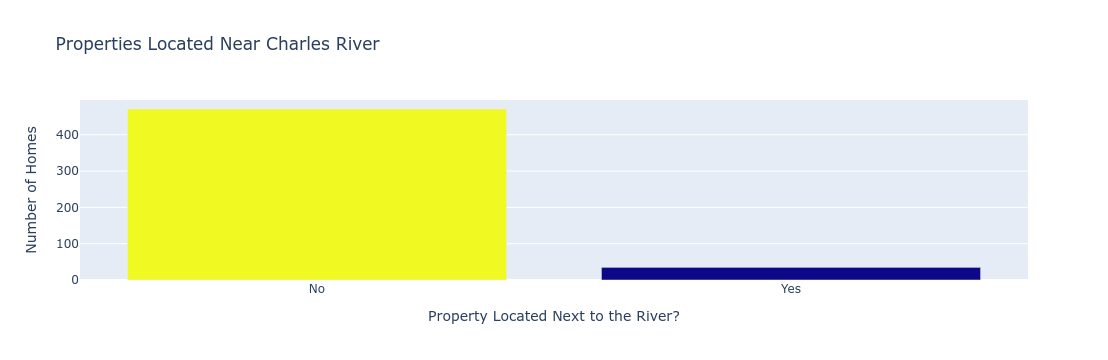

In [9]:
river_access = data['CHAS'].value_counts()

bar = px.bar(x=['No', 'Yes'],
             y=river_access.values,
             color=river_access.values,
             title='Properties Located Near Charles River')

bar.update_layout(xaxis_title='Property Located Next to the River?', 
                  yaxis_title='Number of Homes',
                  coloraxis_showscale=False)
bar.show()

---
## 🕵 Exploring Relationships Between Variables

Pair plots allow visualization of relationships between all variables simultaneously.

This step helps identify:

- correlations
- linear patterns
- potential multicollinearity

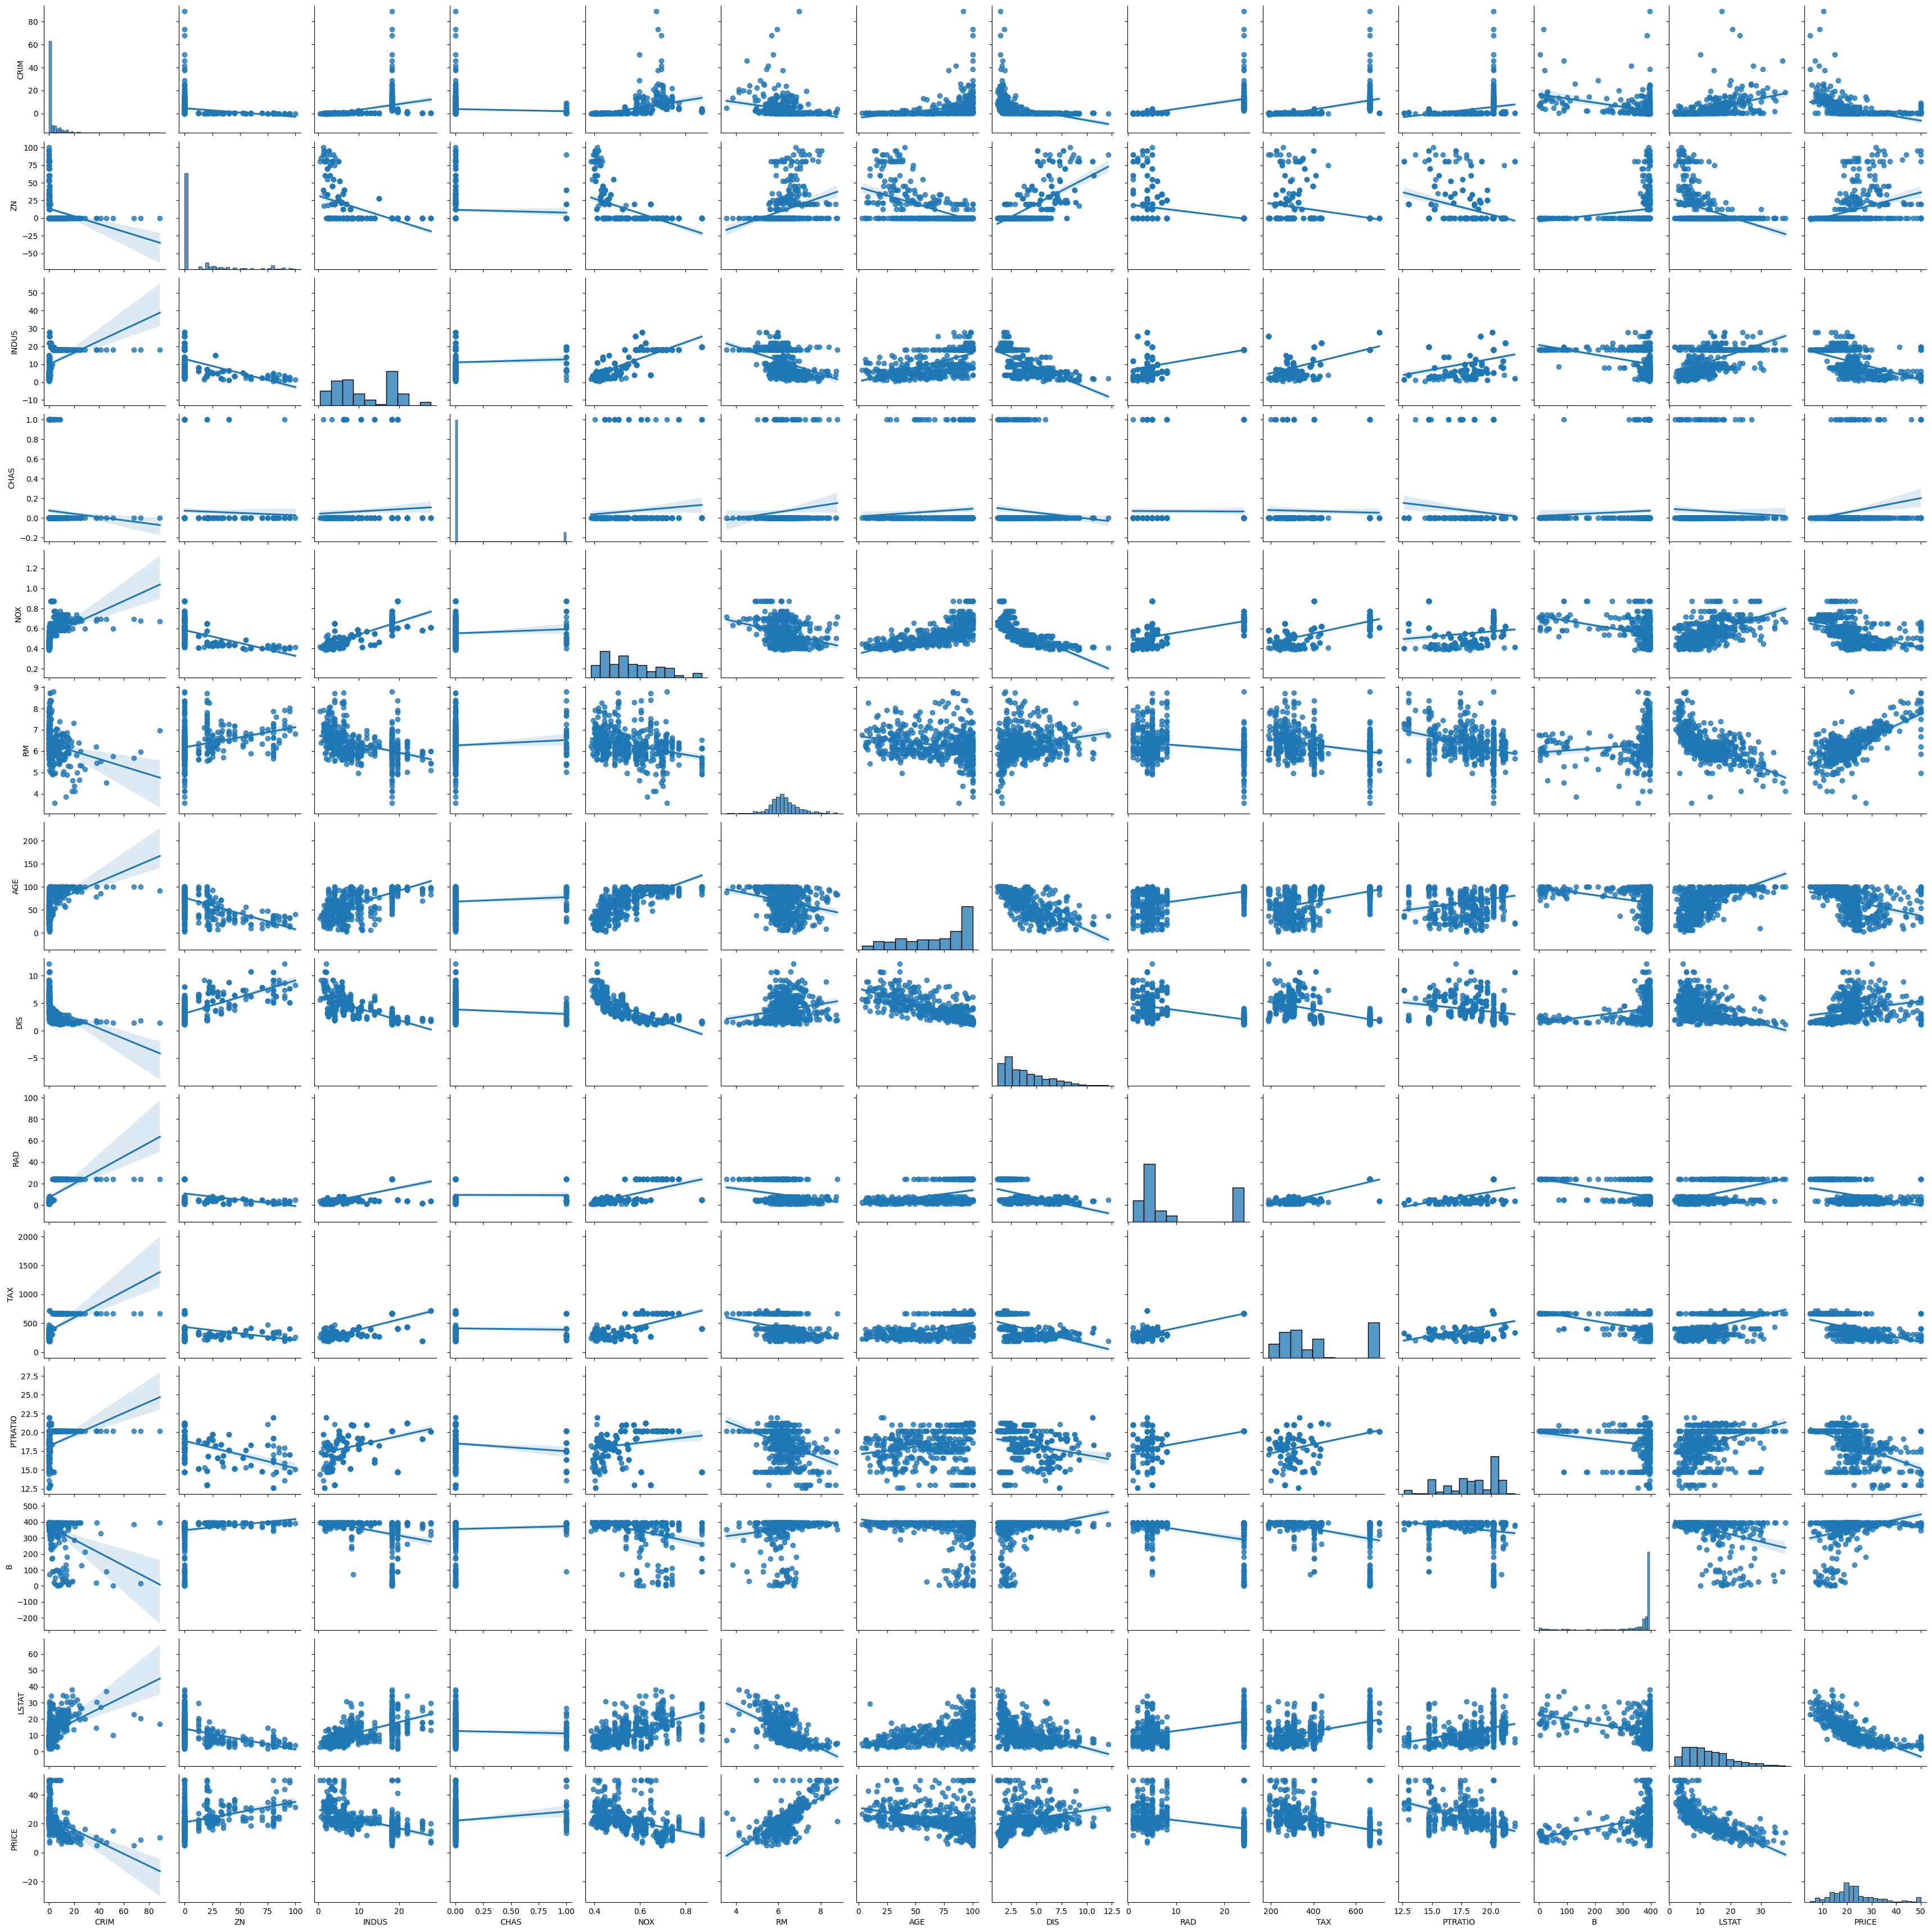

In [10]:
sns.pairplot(data, kind="reg")
plt.show()

### Selected Relationship Analysis

Some relationships deserve closer attention:

- Distance to employment vs pollution
- Proportion of Non-Retail Industry vs Pollution
- Poverty level vs Average Number of Rooms
- Poverty levels vs housing size
- Number of rooms vs housing price

These comparisons help interpret **socioeconomic dynamics** within the dataset.

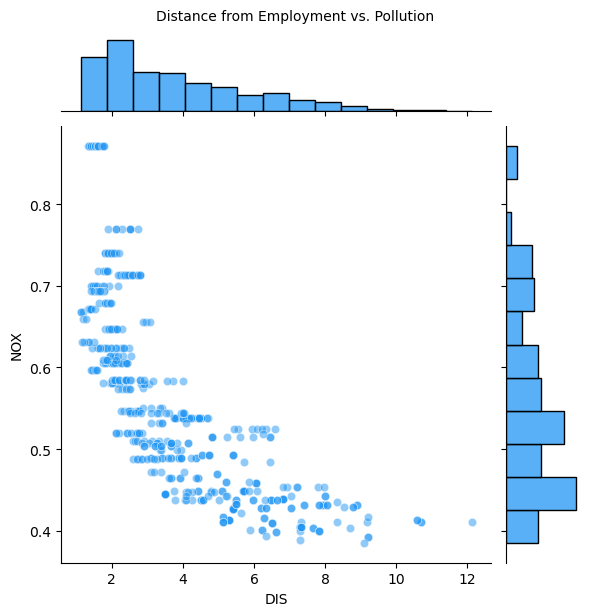

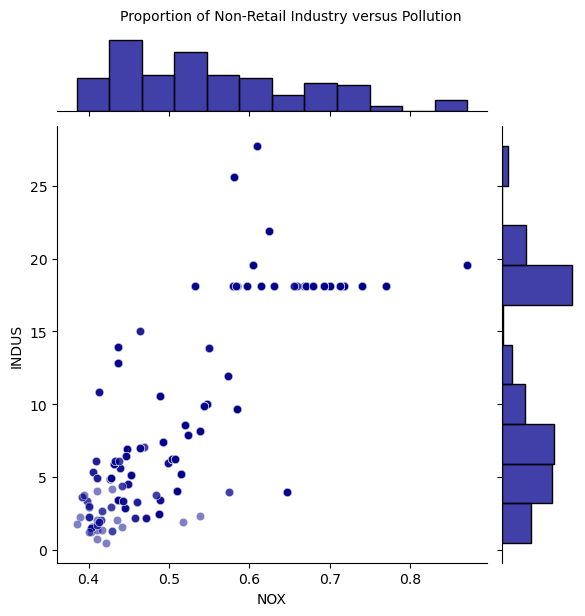

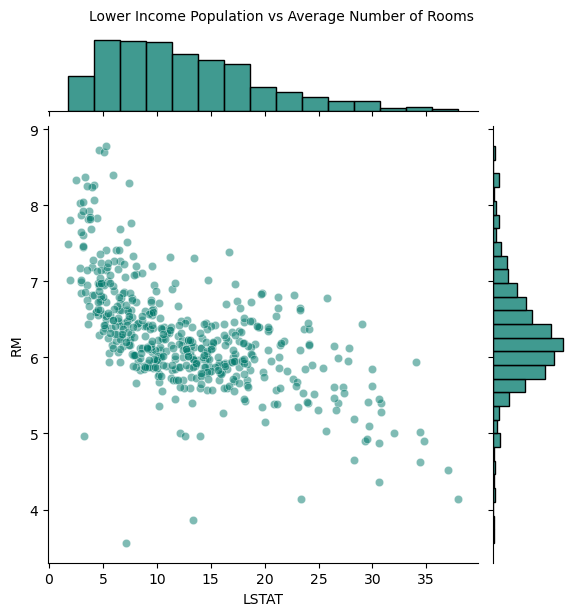

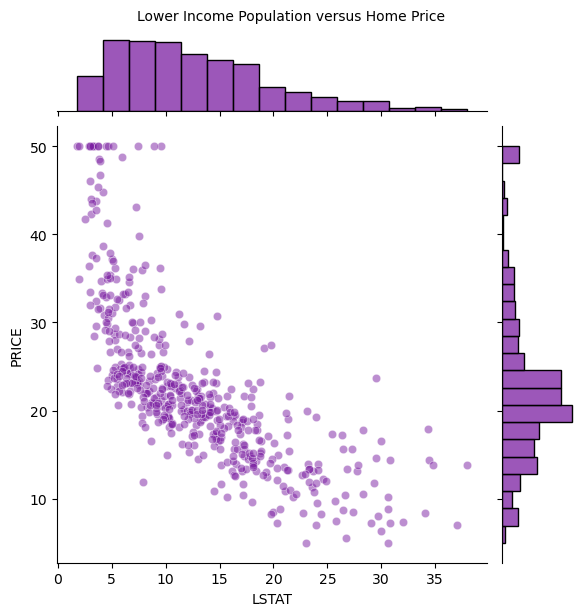

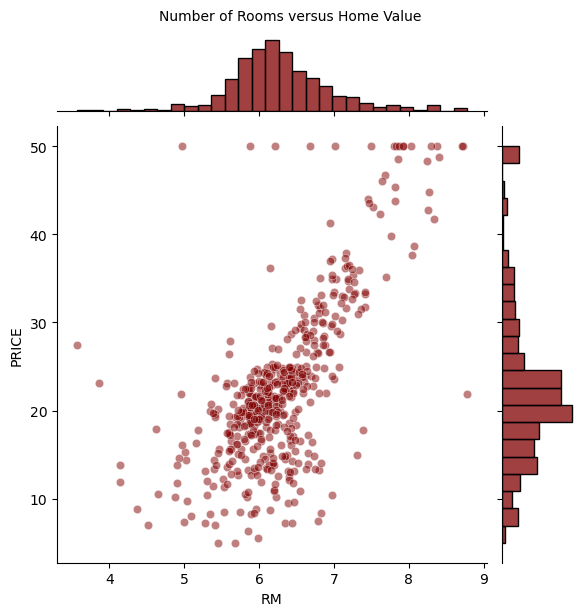

In [11]:
column_pairs = [['DIS','NOX'],['NOX','INDUS'],['LSTAT','RM'],['LSTAT','PRICE'],['RM','PRICE']]
column_names = ['Distance from Employment vs. Pollution','Proportion of Non-Retail Industry versus Pollution',
                'Lower Income Population vs Average Number of Rooms','Lower Income Population versus Home Price',
                'Number of Rooms versus Home Value']
colors = ['#2196f3','darkblue','#00796b','#7b1fa2','#800000']
for pair, title,color in zip(column_pairs, column_names,colors):
    g = sns.jointplot(x=data[pair[0]], y=data[pair[1]], kind='scatter',color=color, 
                joint_kws={'alpha':0.5})
    g.fig.suptitle(title, fontsize=10, y=1.02)

*Insights:*

- The pollution goes down as a person goes further and further out of town.
- There are very different levels of pollution even at the same distance of 2 miles to employment centers.
- All the homes with 8 or more rooms, LSTAT is well below 10%.
- Homes at the $50,000 mark all lined up at the top of the chart. Perhaps there was some sort of cap or maximum value imposed during data collection.

---

## ✂ Splitting Training and Testing Data

Machine learning models must be evaluated using unseen data.

The dataset will be divided:

- 80% training
- 20% testing

In [12]:
target = data["PRICE"]
features = data.drop("PRICE", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=10
)

In [13]:
# % of training set
train_pct = 100*len(X_train)/len(features)
print(f'Training data is {train_pct:.3}% of the total data.')

# % of test data set
test_pct = 100*X_test.shape[0]/features.shape[0]
print(f'Test data makes up the remaining {test_pct:0.3}%.')

Training data is 79.8% of the total data.
Test data makes up the remaining 20.2%.


### Training the Regression Model

A multivariable **linear regression model** is trained using the training dataset.

The resulting model estimates:

$$ PRICE = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta _3 DIS + \theta _4 CHAS ... + \theta _{13} LSTAT$$

In [14]:
regr = LinearRegression()
regr.fit(X_train, y_train)
rsquared = regr.score(X_train, y_train)

print(f"Training R²: {rsquared:.3f}")

Training R²: 0.750


### Model Coefficients

Regression coefficients represent the marginal contribution of each feature.

**Positive** values indicate **increasing prices**, while **negative** values indicate **decreasing prices**.

In [15]:
regr_coef = pd.DataFrame(data=regr.coef_, index=X_train.columns, columns=['Coefficient'])
regr_coef

,Coefficient
CRIM,-0.13
ZN,0.06
INDUS,-0.01
CHAS,1.97
NOX,-16.27
RM,3.11
AGE,0.02
DIS,-1.48
RAD,0.30
TAX,-0.01


### Residual Analysis

Residuals represent the difference between:

> Actual value - Predicted value

A good model should produce residuals that appear randomly distributed.

In [16]:
predicted_vals = regr.predict(X_train)
residuals = (y_train - predicted_vals)

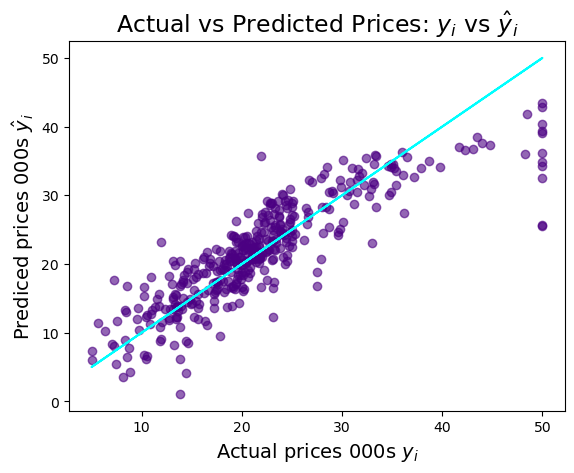

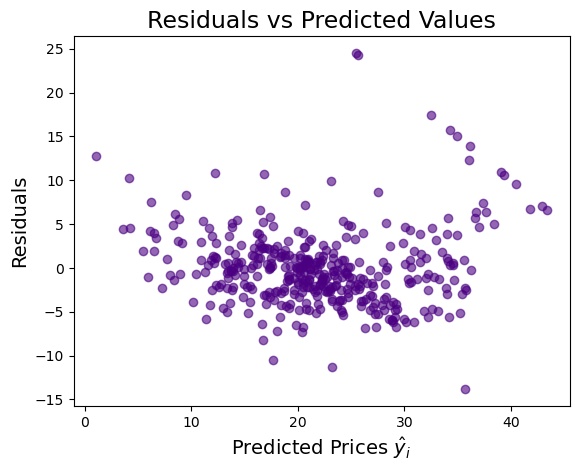

In [17]:
# Original Regression of Actual vs. Predicted Prices
plt.figure(dpi=100)
plt.scatter(x=y_train, y=predicted_vals, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.title(r'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
plt.xlabel(r'Actual prices 000s $y _i$', fontsize=14)
plt.ylabel(r'Prediced prices 000s $\hat y _i$', fontsize=14)
plt.show()

# Residuals vs Predicted values
plt.figure(dpi=100)
plt.scatter(x=predicted_vals, y=residuals, c='indigo', alpha=0.6)
plt.title(r'Residuals vs Predicted Values', fontsize=17)
plt.xlabel(r'Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel(r'Residuals', fontsize=14)
plt.show()

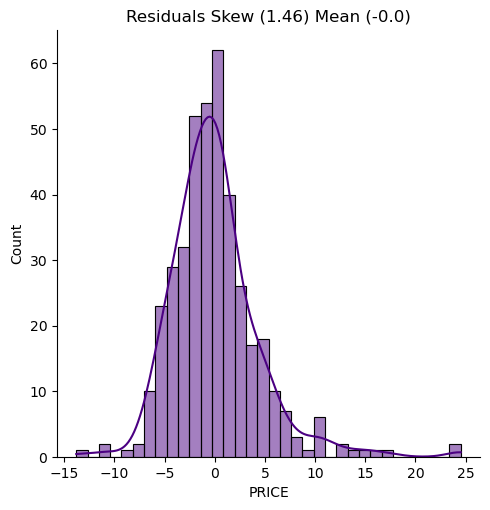

In [18]:
# Residual Distribution Chart
resid_mean = round(residuals.mean(), 2)
resid_skew = round(residuals.skew(), 2)

sns.displot(residuals, kde=True, color='indigo')
plt.title(f'Residuals Skew ({resid_skew}) Mean ({resid_mean})')
plt.show()

The residuals have a skewness of 1.46. There could be some room for improvement here.  

### Improving the Model with Log Transformation

Housing prices show positive skewness, which can affect regression performance.

A logarithmic transformation can stabilize variance and improve model accuracy.

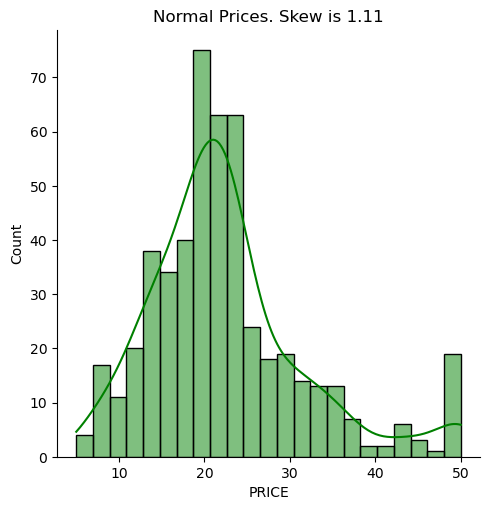

In [19]:
tgt_skew = data['PRICE'].skew()
sns.displot(data['PRICE'], kde='kde', color='green')
plt.title(f'Normal Prices. Skew is {tgt_skew:.3}')
plt.show()

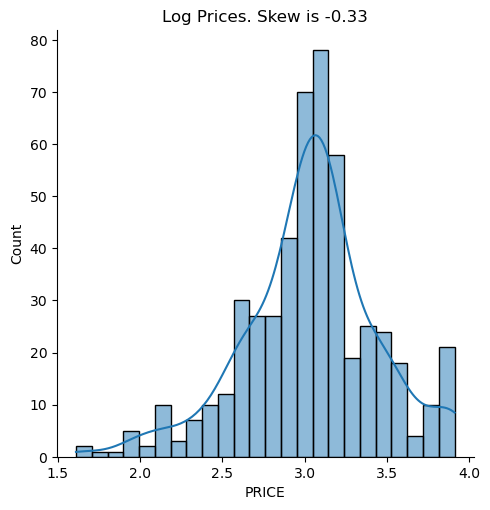

In [20]:
y_log = np.log(data['PRICE'])
sns.displot(y_log, kde=True)
plt.title(f'Log Prices. Skew is {y_log.skew():.3}')
plt.show()

The log prices have a skew that's closer to zero. This makes them a good candidate for use in the linear model.

---

## Regression with Log Prices

The model is retrained using the log-transformed target variable.

In [21]:
new_target = np.log(data['PRICE']) # Use log prices
features = data.drop('PRICE', axis=1)

X_train, X_test, log_y_train, log_y_test = train_test_split(features, 
                                                    new_target, 
                                                    test_size=0.2, 
                                                    random_state=10)

log_regr = LinearRegression()
log_regr.fit(X_train, log_y_train)
log_rsquared = log_regr.score(X_train, log_y_train)

log_predictions = log_regr.predict(X_train)
log_residuals = (log_y_train - log_predictions)

print(f'Training data r-squared: {log_rsquared:.2}')

Training data r-squared: 0.79


This time the r-squared of 0.79 compared to 0.75. This looks like a promising improvement.

---

## 🆚 Model Comparison

Comparing both models helps determine whether the transformation improved predictive accuracy.

In [22]:
df_coef = pd.DataFrame(data=log_regr.coef_, index=X_train.columns, columns=['coef'])
df_coef

,coef
CRIM,-0.01
ZN,0.00
INDUS,0.00
CHAS,0.08
NOX,-0.70
RM,0.07
AGE,0.00
DIS,-0.05
RAD,0.01
TAX,-0.00


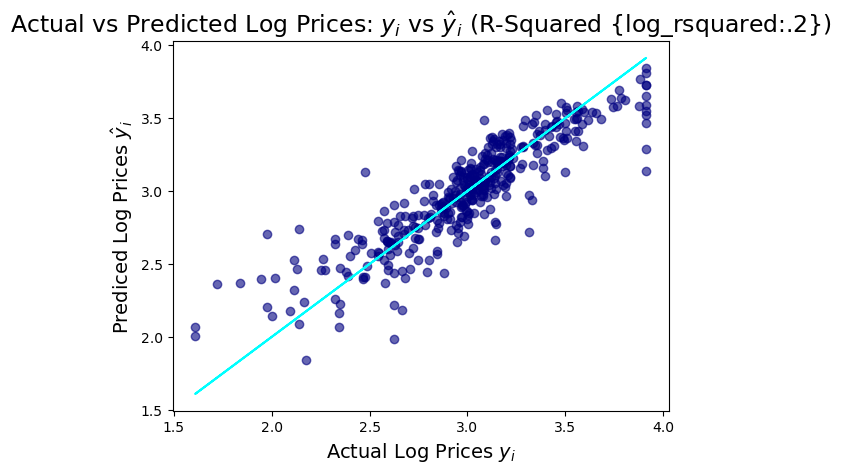

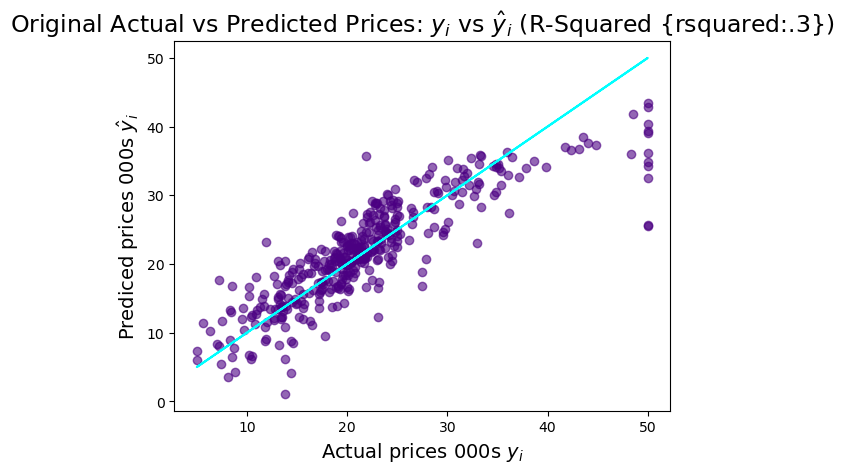

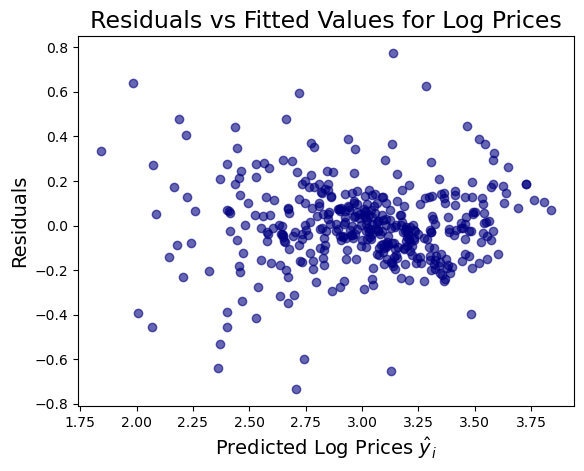

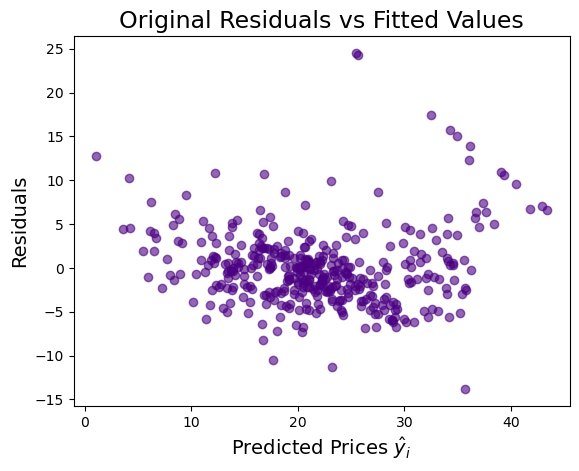

In [23]:
# Graph of Actual vs. Predicted Log Prices
plt.scatter(x=log_y_train, y=log_predictions, c='navy', alpha=0.6)
plt.plot(log_y_train, log_y_train, color='cyan')
plt.title(r'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared:.2})', fontsize=17)
plt.xlabel(r'Actual Log Prices $y _i$', fontsize=14)
plt.ylabel(r'Prediced Log Prices $\hat y _i$', fontsize=14)
plt.show()

# Original Regression of Actual vs. Predicted Prices
plt.scatter(x=y_train, y=predicted_vals, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.title(r'Original Actual vs Predicted Prices: $y _i$ vs $\hat y_i$ (R-Squared {rsquared:.3})', fontsize=17)
plt.xlabel(r'Actual prices 000s $y _i$', fontsize=14)
plt.ylabel(r'Prediced prices 000s $\hat y _i$', fontsize=14)
plt.show()

# Residuals vs Predicted values (Log prices)
plt.scatter(x=log_predictions, y=log_residuals, c='navy', alpha=0.6)
plt.title(r'Residuals vs Fitted Values for Log Prices', fontsize=17)
plt.xlabel(r'Predicted Log Prices $\hat y _i$', fontsize=14)
plt.ylabel(r'Residuals', fontsize=14)
plt.show()

# Residuals vs Predicted values
plt.scatter(x=predicted_vals, y=residuals, c='indigo', alpha=0.6)
plt.title(r'Original Residuals vs Fitted Values', fontsize=17)
plt.xlabel(r'Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel(r'Residuals', fontsize=14)
plt.show()

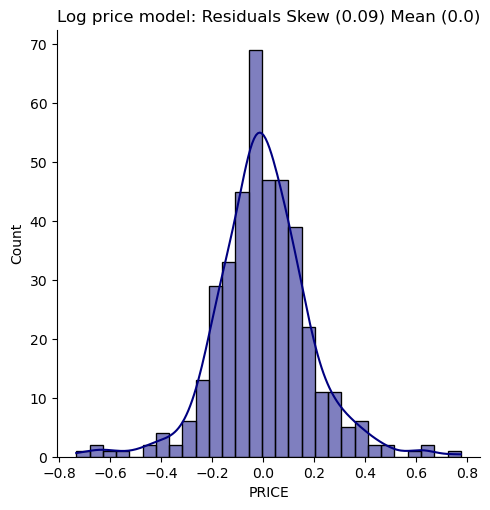

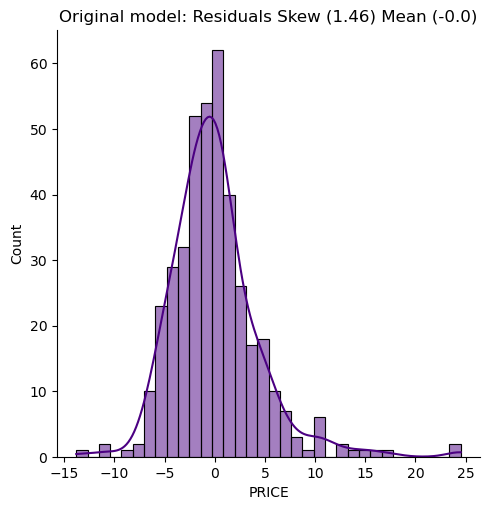

In [24]:
# Distribution of Residuals (log prices) - checking for normality
log_resid_mean = round(log_residuals.mean(), 2)
log_resid_skew = round(log_residuals.skew(), 2)

sns.displot(log_residuals, kde=True, color='navy')
plt.title(f'Log price model: Residuals Skew ({log_resid_skew}) Mean ({log_resid_mean})')
plt.show()

sns.displot(residuals, kde=True, color='indigo')
plt.title(f'Original model: Residuals Skew ({resid_skew}) Mean ({resid_mean})')
plt.show()

In [25]:
print(f'Original Model Test Data r-squared: {regr.score(X_test, y_test):.2}')
print(f'Log Model Test Data r-squared: {log_regr.score(X_test, log_y_test):.2}')

Original Model Test Data r-squared: 0.67
Log Model Test Data r-squared: 0.74


The new regression residuals have a skew of 0.09 compared to a skew of 1.46. The mean is still around 0. From both a residuals perspective and an r-squared perspective we have improved our model with the data transformation.

---

## 🎯 Property Value Prediction

The preferred model now has an equation that looks like this:

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$

Using average feature values, the model can estimate the expected price of a typical property.

In [26]:
# Starting Point: Average Values in the Dataset
features = data.drop(['PRICE'], axis=1)
average_vals = features.mean().values
property_stats = pd.DataFrame(data=average_vals.reshape(1, len(features.columns)), 
                              columns=features.columns)
property_stats

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65


In [27]:
# Make prediction
log_estimate = log_regr.predict(property_stats)[0]
print(f'The log price estimate is ${log_estimate:.3}')

# Convert Log Prices to Acutal Dollar Values
dollar_est = np.e**log_estimate * 1000
# or use
dollar_est = np.exp(log_estimate) * 1000
print(f'Estimated property value: ${dollar_est:.6}')

The log price estimate is $3.03
Estimated property value: $20703.2
